Importation et analyse des données World Cities Culture pour faire de la data augmentation et apporter plus d'impact a mes données

# Importation des bibliothèques

In [72]:
import pandas as pd
import os
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import osmnx as ox
import geopandas as gpd

# Configuration

In [73]:
# Charger les variables d'environnement depuis .env
load_dotenv()

POSTGRES_USER = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")
POSTGRES_HOST = os.getenv("POSTGRES_HOST", "localhost")
POSTGRES_PORT = os.getenv("POSTGRES_PORT", "5432")
POSTGRES_DB = os.getenv("POSTGRES_DB")

DATABASE_URL = f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"

print(f"✅ Connexion configurée vers : {POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}")

✅ Connexion configurée vers : localhost:5432/webscrap


In [74]:
engine = create_engine(DATABASE_URL)

# Test de connexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print("✅ Connecté à PostgreSQL :", result.fetchone()[0])

✅ Connecté à PostgreSQL : PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35223, 64-bit


# Data augmentation ❌
Pas utilisé

## Importation des datasets

In [32]:
df_number_tourist = pd.read_csv(r"../DATA/raw/world_cities_culture/annual-number-of-tourists-data.csv")
df_park = pd.read_csv(r"../DATA/raw/world_cities_culture/area-of-free--publicly-accessible-parks-and-gardens-as---of-total-city-area-data.csv")
df_bar = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-bars-data.csv")
df_museum = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-museums-data.csv")
df_disco = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-night-clubs--discos-and-dance-halls-data.csv")
df_resto = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-restaurants-data.csv")
df_UNESCO = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-unesco-world-heritage-sites-within-city-boundaries-data.csv")
df_site_historique = pd.read_csv(r"../DATA/raw/world_cities_culture/no--of-heritage-historical-sites--excluding-museums--data.csv")

## Création d'un unique dataset

In [33]:
df = [df_number_tourist, df_park, df_bar, df_museum, df_disco, df_resto, df_UNESCO, df_site_historique]

In [34]:
names = ['nb_touristes', 'nb_park', 'nb_bar', 'nb_museum', 'nb_disco', 'nb_resto', 'nb_unesco', 'nb_site_historique']

new_df = []

for i, name in zip(df, names):
    i = i.copy()  # éviter les effets de bord
    
    # 🔤 renommer une colonne
    i = i.rename(columns={
        'Value': f'valeur_{name}'
    })
    
    # 🗑️ supprimer des colonnes
    i = i.drop(columns=['Source', 'Notes', 'Date'], errors='ignore')
    
    new_df.append(i)



In [35]:
final_df = new_df[0].copy()

for df in new_df[1:]:
    final_df = final_df.merge(df, on='City', how='outer')

In [37]:
final_df

,City,valeur_nb_touristes,valeur_nb_park,valeur_nb_bar,valeur_nb_museum,valeur_nb_disco,valeur_nb_resto,valeur_nb_unesco,valeur_nb_site_historique
0,Abu Dhabi,4800000.0,NaN,NaN,7.0,NaN,NaN,NaN,221.0
1,Adelaide,3422000.0,0.2760,NaN,29.0,NaN,NaN,NaN,NaN
2,Amsterdam,24500000.0,NaN,905.0,73.0,541.0,1861.0,2,9796.0
3,Austin,27400000.0,NaN,308.0,25.0,280.0,4755.0,0,10.0
4,Barcelona,15600000.0,NaN,429.0,61.0,97.0,3054.0,8,1492.0
5,Beijing,371529000.0,NaN,NaN,241.0,NaN,5675.0,8,NaN
6,Boston,40800000.0,0.1638,118.0,18.0,118.0,975.0,NaN,NaN
7,Brasilia,68000.0,NaN,NaN,20.0,NaN,NaN,1,20.0
8,Brussels,3600000.0,NaN,NaN,45.0,NaN,NaN,NaN,NaN
9,Chengdu,306000000.0,0.0110,5000.0,196.0,NaN,300000.0,1,165.0


In [9]:
df_destinations= pd.read_csv(r"../DATA/processed/destinations.csv")
df_destinations.

,City,country,code_3L,region,short_description,latitude,longitude
0,Luanda,angola,AGO,africa,"A bustling port city with vibrant markets, liv...",-8.827270,13.243951
1,Bujumbura,burundi,BDI,africa,A city where vibrant street markets and lush l...,-3.363812,29.367503
2,Dhaka,bangladesh,BGD,asia,"A whirlwind of vibrant street life, bustling m...",23.764386,90.389014
3,Maun,botswana,BWA,africa,"A gateway to the Okavango Delta, offering a se...",-19.986095,23.422435
4,Whistler,canada,CAN,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302


# Data augmentation : Open Street Map ✅

Ajout de données pour :
- augmenter la pertinence des différentes activités
- un meilleur entrainement du model

In [64]:
# ─── Structure principale : catégorie → valeurs OSM ──────────────────────────

CATEGORIES = {
    "nature": [
        "beach", "cliff", "cave_entrance", "peak", "hot_spring", "waterfall",  # natural
        "park", "garden", "nature_reserve", "bird_hide", "marina",              # leisure
        "beach_resort", "picnic_table", "slipway",
        "picnic_site", "viewpoint",                                              # tourism
    ],
    "patrimoine": [
        "monument", "memorial", "castle", "ruins", "archaeological_site",       # historic
        "building", "church", "manor", "fort", "palace", "tower",
        "city_gate", "aqueduct", "battlefield",
        "attraction",                                                            # tourism
        "place_of_worship", "fountain",                                         # amenity
    ],
    "culture": [
        "museum", "gallery", "zoo", "theme_park", "aquarium", "artwork",        # tourism
        "theatre", "arts_centre", "cinema", "music_venue", "library",           # amenity
        "university", "college", "events_venue", "exhibition_centre",
        "conference_centre", "community_centre",
    ],
    "restaurant": [
        "restaurant", "cafe", "fast_food", "ice_cream",                         # amenity
        "food_court", "marketplace",
    ],
    "nightlife": [
        "bar", "pub", "nightclub", "casino", "biergarten",                      # amenity
        "lounge", "hookah_lounge",
    ],
    "loisirs": [
        "sports_centre", "swimming_pool", "stadium", "golf_course",             # leisure
        "amusement_arcade", "miniature_golf", "fitness_centre",
        "bowling_alley", "water_park", "horse_riding", "ice_rink",
        "playground", "escape_game", "dance",
        "hotel", "hostel", "guest_house", "camp_site", "information",           # tourism
        "ferry_terminal", "public_bath",                                         # amenity
    ],
}

# ─── Mapping coulisses : valeur → clé OSM ────────────────────────────────────

VALUE_TO_OSM_KEY = {
    # natural
    "beach": "natural", "cliff": "natural", "cave_entrance": "natural",
    "peak": "natural", "hot_spring": "natural", "waterfall": "natural",
    # leisure
    "park": "leisure", "garden": "leisure", "nature_reserve": "leisure",
    "bird_hide": "leisure", "marina": "leisure", "beach_resort": "leisure",
    "picnic_table": "leisure", "slipway": "leisure", "sports_centre": "leisure",
    "swimming_pool": "leisure", "stadium": "leisure", "golf_course": "leisure",
    "amusement_arcade": "leisure", "miniature_golf": "leisure",
    "fitness_centre": "leisure", "bowling_alley": "leisure",
    "water_park": "leisure", "horse_riding": "leisure", "ice_rink": "leisure",
    "playground": "leisure", "escape_game": "leisure", "dance": "leisure",
    # tourism
    "picnic_site": "tourism", "viewpoint": "tourism", "attraction": "tourism",
    "museum": "tourism", "gallery": "tourism", "zoo": "tourism",
    "theme_park": "tourism", "aquarium": "tourism", "artwork": "tourism",
    "hotel": "tourism", "hostel": "tourism", "guest_house": "tourism",
    "camp_site": "tourism", "information": "tourism",
    # historic
    "monument": "historic", "memorial": "historic", "castle": "historic",
    "ruins": "historic", "archaeological_site": "historic", "building": "historic",
    "church": "historic", "manor": "historic", "fort": "historic",
    "palace": "historic", "tower": "historic", "city_gate": "historic",
    "aqueduct": "historic", "battlefield": "historic",
    # amenity
    "place_of_worship": "amenity", "fountain": "amenity", "theatre": "amenity",
    "arts_centre": "amenity", "cinema": "amenity", "music_venue": "amenity",
    "library": "amenity", "university": "amenity", "college": "amenity",
    "events_venue": "amenity", "exhibition_centre": "amenity",
    "conference_centre": "amenity", "community_centre": "amenity",
    "restaurant": "amenity", "cafe": "amenity", "fast_food": "amenity",
    "ice_cream": "amenity", "food_court": "amenity", "marketplace": "amenity",
    "bar": "amenity", "pub": "amenity", "nightclub": "amenity",
    "casino": "amenity", "biergarten": "amenity", "lounge": "amenity",
    "hookah_lounge": "amenity", "ferry_terminal": "amenity", "public_bath": "amenity",
}

# ─── Construction des tags OSM pour la requête (coulisses) ───────────────────

def build_osm_tags(categories: dict, value_to_osm_key: dict) -> dict:
    osm_tags = {}
    for values in categories.values():
        for value in values:
            osm_key = value_to_osm_key[value]
            osm_tags.setdefault(osm_key, set()).add(value)
    return {k: list(v) for k, v in osm_tags.items()}

# ─── Assignation de catégorie ─────────────────────────────────────────────────

def assign_category(row: pd.Series, categories: dict, value_to_osm_key: dict) -> str:
    for category, values in categories.items():
        for value in values:
            osm_key = value_to_osm_key[value]
            if osm_key in row.index and pd.notna(row[osm_key]) and row[osm_key] == value:
                return category
    return "autre"

# ─── Récupération des POI pour une liste de villes ───────────────────────────

def fetch_pois(cities: list[str]) -> gpd.GeoDataFrame:
    osm_tags = build_osm_tags(CATEGORIES, VALUE_TO_OSM_KEY)
    all_pois = []

    for city in cities:
        try:
            pois = ox.features_from_place(city, osm_tags)
            pois["city"] = city
            pois["category"] = pois.apply(
                lambda row: assign_category(row, CATEGORIES, VALUE_TO_OSM_KEY), axis=1
            )
            pois = pois[pois["category"] != "autre"]
            all_pois.append(pois)
            print(f"✅ {city} : {len(pois)} POI")

        except Exception as e:
            print(f"❌ {city} : {e}")

    return gpd.GeoDataFrame(pd.concat(all_pois, ignore_index=True))

# ─── Utilisation ─────────────────────────────────────────────────────────────

cities = (df_destinations['City'] + ", " + df_destinations['country']).tolist()
gdf = fetch_pois(cities)

summary = (
    gdf.groupby(["city", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["nature", "patrimoine", "culture", "restaurant", "nightlife", "loisirs"])
)
print(summary)

✅ Luanda, angola : 978 POI
❌ Bujumbura, burundi : Nominatim did not geocode query 'Bujumbura, burundi' to a geometry of type (Multi)Polygon.


C:\Users\Utilisateur\anaconda3\envs\FinalProject\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


✅ Dhaka, bangladesh : 12747 POI
❌ Maun, botswana : Nominatim did not geocode query 'Maun, botswana' to a geometry of type (Multi)Polygon.
✅ Whistler, canada : 714 POI
✅ Toronto, canada : 22184 POI
✅ Edmonton, canada : 5896 POI
✅ Banff, canada : 343 POI
✅ Québec City, canada : 4105 POI
✅ Charlottetown, canada : 648 POI
✅ Calgary, canada : 10486 POI
✅ Halifax, canada : 1643 POI
✅ Ottawa, canada : 12323 POI
✅ Montreal, canada : 14237 POI
✅ Vancouver, canada : 7122 POI
✅ Quebec City, canada : 4105 POI
✅ Niagara Falls, canada : 1145 POI


C:\Users\Utilisateur\anaconda3\envs\FinalProject\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 16 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


✅ Vancouver Island, canada : 14515 POI
✅ Monteverde, costa rica : 307 POI
✅ San José, costa rica : 5750 POI
✅ Manuel Antonio National Park, costa rica : 40 POI
✅ Havana, cuba : 9512 POI
❌ Trinidad, cuba : 'overpass-api.de' responded: 400 Bad Request <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">
<head>
  <meta http-equiv="content-type" content="text/html; charset=utf-8" lang="en"/>
  <title>OSM3S Response</title>
</head>
<body>

<p>The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.</p>
<p><strong style="color:#FF0000">Error</strong>: encoding error: Input Input too long (length: 17152990). The maximum query length is 16 MB. </p>

</body>
</html>

✅ Marseille, france : 11331 POI
✅ Annecy, france : 2378 POI
✅ Nantes, france : 5597 POI
✅ Bordeaux, france : 5186 POI

...

✅ Azores, portugal : 7027 POI
✅ Madeira, portugal : 8608 POI
❌ Lagos, portugal : 'overpass-api.de' responded: 400 Bad Request <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">
<head>
  <meta http-equiv="content-type" content="text/html; charset=utf-8" lang="en"/>
  <title>OSM3S Response</title>
</head>
<body>

<p>The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.</p>
<p><strong style="color:#FF0000">Error</strong>: encoding error: Input Input too long (length: 17369962). The maximum query length is 16 MB. </p>

</body>
</html>

✅ Sintra, portugal : 6317 POI
✅ Lisbon, portugal : 10346 POI
✅ Algarve, portugal : 2 POI
✅ Guimarães, portugal : 1516 POI
❌ Vilamoura, portugal : Nominatim did not geocode query 'Vilamoura, portugal' to a geometry of type (Multi)Polygon.
✅ B

C:\Users\Utilisateur\anaconda3\envs\FinalProject\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 175 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


❌ Seychelles, seychelles : HTTPSConnectionPool(host='overpass-api.de', port=443): Read timed out. (read timeout=180)
✅ Lomé, togo : 2124 POI
❌ Nukuʻalofa, tonga : Nominatim did not geocode query 'Nukuʻalofa, tonga' to a geometry of type (Multi)Polygon.
✅ Odessa, ukraine : 3249 POI
✅ Kyiv, ukraine : 15139 POI
✅ Lviv, ukraine : 3960 POI
❌ Montevideo, uruguay : 'overpass-api.de' responded: 400 Bad Request <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">
<head>
  <meta http-equiv="content-type" content="text/html; charset=utf-8" lang="en"/>
  <title>OSM3S Response</title>
</head>
<body>

<p>The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.</p>
<p><strong style="color:#FF0000">Error</strong>: encoding error: Input Input too long (length: 38509738). The maximum query l

C:\Users\Utilisateur\anaconda3\envs\FinalProject\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 22 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


✅ Ho Chi Minh City, vietnam : 12722 POI
✅ Hanoi, vietnam : 8849 POI
✅ Hue, vietnam : 1987 POI
✅ Ha Long, vietnam : 8849 POI
❌ Port Vila, vanuatu : Nominatim did not geocode query 'Port Vila, vanuatu' to a geometry of type (Multi)Polygon.
❌ Tanna Island, vanuatu : 'overpass-api.de' responded: 400 Bad Request <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en" lang="en">
<head>
  <meta http-equiv="content-type" content="text/html; charset=utf-8" lang="en"/>
  <title>OSM3S Response</title>
</head>
<body>

<p>The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.</p>
<p><strong style="color:#FF0000">Error</strong>: encoding error: Input Input too long (length: 41725258). The maximum query length is 16 MB. </p>

</body>
</html>

✅ Espiritu Santo, vanuatu : 160 POI
✅ Apia, samoa : 5 POI


## Analyse de summary

In [65]:
summary.head()

category,nature,patrimoine,culture,restaurant,nightlife,loisirs
city,,,,,,
"Accra, ghana",70,776,125,1029,437,804
"Ajaccio, france",81,73,36,189,35,308
"Algarve, portugal",0,0,0,1,0,1
"Annecy, france",361,164,166,476,61,1150
"Apia, samoa",1,4,0,0,0,0


<Axes: >

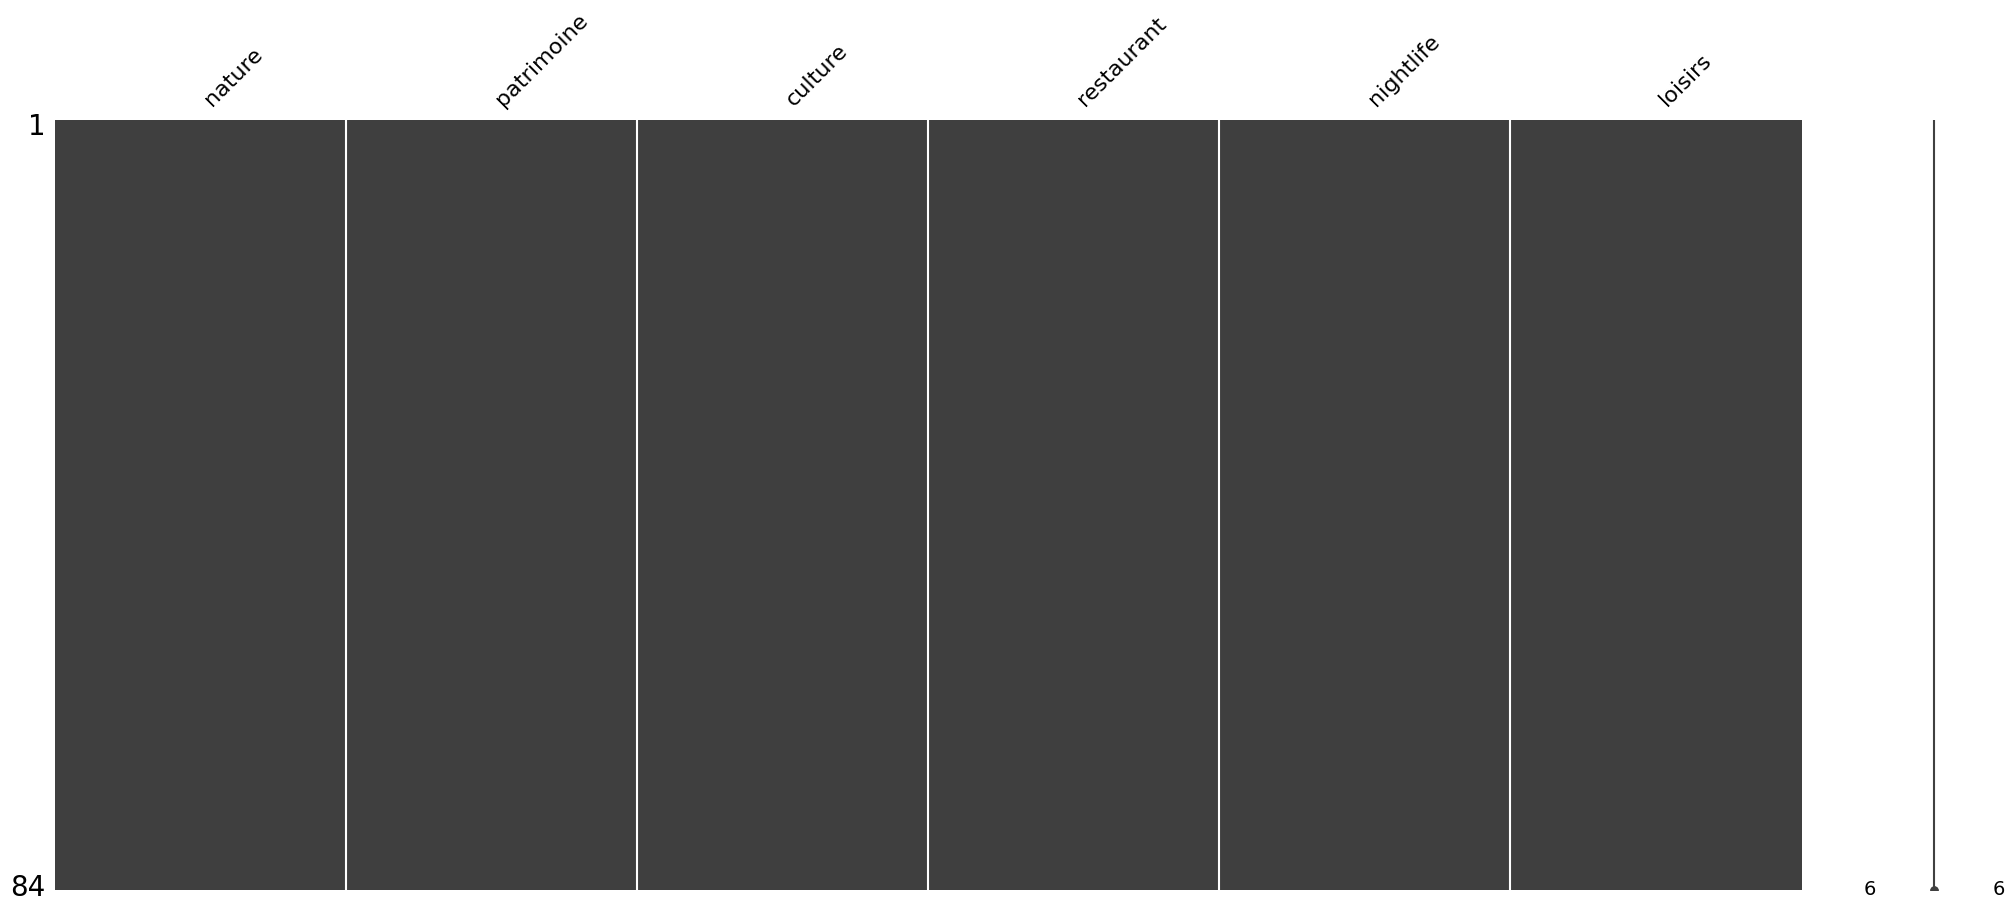

In [67]:
import missingno as msno
msno.matrix(summary)

In [69]:
summary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, Accra, ghana to Whistler, canada
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   nature      84 non-null     int64
 1   patrimoine  84 non-null     int64
 2   culture     84 non-null     int64
 3   restaurant  84 non-null     int64
 4   nightlife   84 non-null     int64
 5   loisirs     84 non-null     int64
dtypes: int64(6)
memory usage: 4.6+ KB


In [70]:
summary = summary.reset_index()
summary.head()

category,city,nature,patrimoine,culture,restaurant,nightlife,loisirs
0,"Accra, ghana",70,776,125,1029,437,804
1,"Ajaccio, france",81,73,36,189,35,308
2,"Algarve, portugal",0,0,0,1,0,1
3,"Annecy, france",361,164,166,476,61,1150
4,"Apia, samoa",1,4,0,0,0,0


In [71]:
summary[['city', 'country']] = summary['city'].str.split(', ', expand=True)
summary.head()

category,city,nature,patrimoine,culture,restaurant,nightlife,loisirs,country
0,Accra,70,776,125,1029,437,804,ghana
1,Ajaccio,81,73,36,189,35,308,france
2,Algarve,0,0,0,1,0,1,portugal
3,Annecy,361,164,166,476,61,1150,france
4,Apia,1,4,0,0,0,0,samoa


## Exportation de summary

In [76]:
output_dir = "../DATA/raw"
os.makedirs(output_dir, exist_ok=True)

summary.to_csv(os.path.join(output_dir, "export_osm.csv"))
summary.to_sql(
    name="export_osm",
    con=engine,
    if_exists="replace",   # 'append' pour ajouter sans écraser
    index=False,
    method="multi",
    chunksize=5000
)
print("FAIT ✅")

FAIT ✅
